<a href="https://colab.research.google.com/github/SnehaPandit10/da-ml-assignment/blob/main/titanic_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

titanic_df = pd.read_csv('titanic.csv')
test_df  = pd.read_csv('test.csv')
combine = [titanic_df, test_df]
combine

[     PassengerId  Pclass                                          Name  \
 0            892       3                              Kelly, Mr. James   
 1            893       3              Wilkes, Mrs. James (Ellen Needs)   
 2            894       2                     Myles, Mr. Thomas Francis   
 3            895       3                              Wirz, Mr. Albert   
 4            896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)   
 ..           ...     ...                                           ...   
 413         1305       3                            Spector, Mr. Woolf   
 414         1306       1                  Oliva y Ocana, Dona. Fermina   
 415         1307       3                  Saether, Mr. Simon Sivertsen   
 416         1308       3                           Ware, Mr. Frederick   
 417         1309       3                      Peter, Master. Michael J   
 
         Sex   Age  SibSp  Parch              Ticket      Fare Cabin Embarked  
 0      male  34.5

In [ ]:
print(test_df.columns.values)

['PassengerId' 'Survived' 'Pclass' 'Name' 'Sex' 'Age' 'SibSp' 'Parch'
 'Ticket' 'Fare' 'Cabin' 'Embarked']


In [ ]:
corr_fare_pclass = test_df['Fare'].corr(test_df['Pclass'])
print(corr_fare_pclass)

-0.5494996199439074


yes

In [ ]:
corr_pclass_survived = test_df['Pclass'].corr(test_df['Survived'])
print(corr_pclass_survived)

-0.33848103596101475


yes

Better ticket class → generally higher chance of survival.

In [ ]:
corr_pclass_age = test_df['Age'].corr(test_df['Pclass'])
print(corr_pclass_age)

-0.36922601531551724


yes

Higher age tends to be associated with better ticket class.

In [ ]:
test_corr = test_df.corr(numeric_only=True)
test_corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [ ]:
test_vc = test_df['Survived'].value_counts()
test_vc

,count
Survived,
0,549
1,342


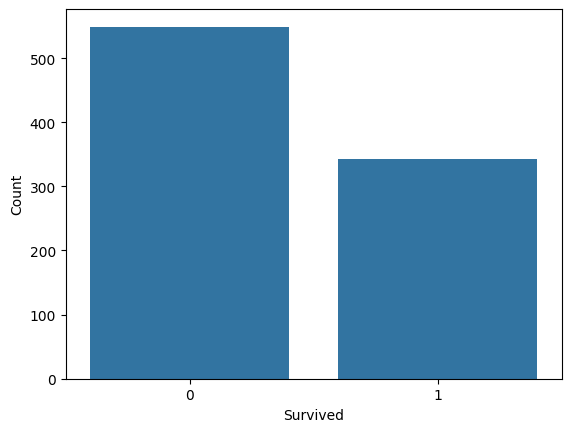

In [ ]:
import seaborn as sns

sns.countplot(x='Survived', data =test_df)
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

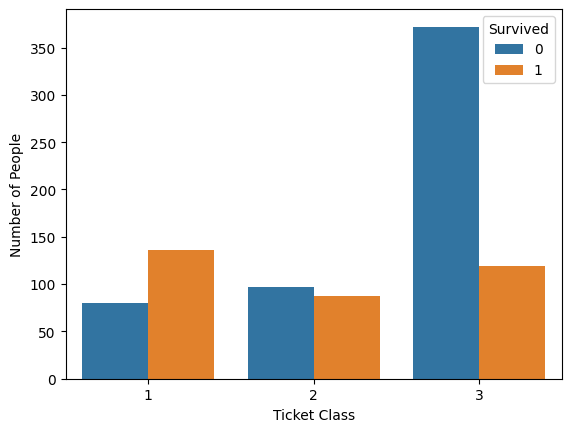

In [ ]:
sns.countplot(x='Pclass', hue='Survived', data=test_df)
plt.xlabel('Ticket Class')
plt.ylabel('Number of People')
plt.show()

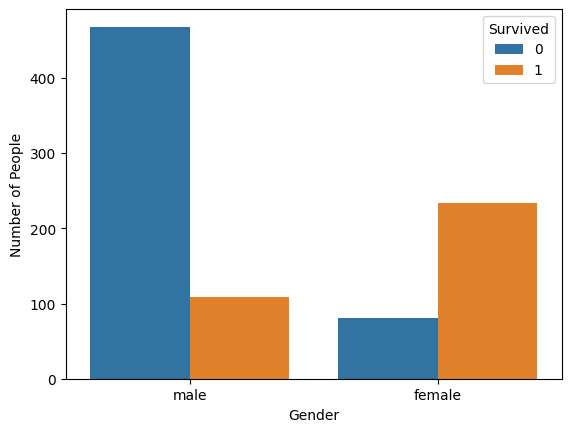

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=test_df)
plt.xlabel('Gender')
plt.ylabel('Number of People')
plt.show()

In [ ]:
# Pclass - 3
# male survived less

In [ ]:
q1= test_df['Fare'].quantile(0.25)
q3= test_df['Fare'].quantile(0.75)
iqr=q3-q1
lower = q1 - 1.5*iqr
higher = q3 + 1.5*iqr
outliers = test_df[(test_df['Fare']<lower) | (test_df['Fare']>higher)]
outliers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.5500,NaN,S
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,NaN,1,0,17453,89.1042,C92,C
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S


In [ ]:
test_df['Age'].isnull().sum()

np.int64(177)

In [ ]:
test_df_copy = test_df.copy()
test_df_copy['Age'].fillna(test_df_copy['Age'].mean(), inplace=True)
test_df_copy['Age'].isnull().sum()

/tmp/ipykernel_3448/230980395.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df_copy['Age'].fillna(test_df_copy['Age'].mean(), inplace=True)


np.int64(0)

In [ ]:
test_df_copy.drop('Cabin',axis=1,inplace = True)
test_df_copy.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
test_df_copy['Sex'] = le.fit_transform(test_df_copy['Sex'])
test_df_copy['Embarked'] = le.fit_transform(test_df_copy['Embarked'])
test_df_copy

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,2
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.000000,0,0,211536,13.0000,2
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.000000,0,0,112053,30.0000,2
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,1,2,W./C. 6607,23.4500,2
889,890,1,1,"Behr, Mr. Karl Howell",1,26.000000,0,0,111369,30.0000,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
test_df_copy[num_cols] = sc.fit_transform(test_df_copy[num_cols])
test_df_copy

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,0.271174,0.125,0.000000,A/5 21171,0.014151,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,0.472229,0.125,0.000000,PC 17599,0.139136,0
2,3,1,3,"Heikkinen, Miss. Laina",0,0.321438,0.000,0.000000,STON/O2. 3101282,0.015469,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,0.434531,0.125,0.000000,113803,0.103644,2
4,5,0,3,"Allen, Mr. William Henry",1,0.434531,0.000,0.000000,373450,0.015713,2
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,0.334004,0.000,0.000000,211536,0.025374,2
887,888,1,1,"Graham, Miss. Margaret Edith",0,0.233476,0.000,0.000000,112053,0.058556,2
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,0.367921,0.125,0.333333,W./C. 6607,0.045771,2
889,890,1,1,"Behr, Mr. Karl Howell",1,0.321438,0.000,0.000000,111369,0.058556,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = test_df_copy.drop('Pclass', axis=1)
y = test_df_copy['Pclass']

X = X.select_dtypes(include='number')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Naive Bayes Accuracy: 0.7374301675977654
Decision Tree Accuracy: 0.9162011173184358


Naive Bayes Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.72      0.81        53
           2       0.40      0.55      0.46        33
           3       0.82      0.82      0.82        93

    accuracy                           0.74       179
   macro avg       0.71      0.69      0.70       179
weighted avg       0.77      0.74      0.75       179



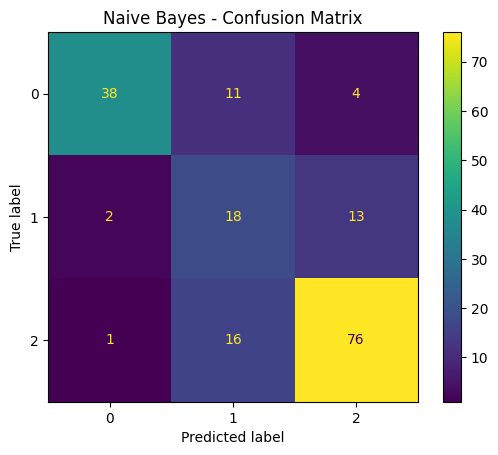

Decision Tree Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.92      0.96        53
           2       0.75      0.82      0.78        33
           3       0.94      0.95      0.94        93

    accuracy                           0.92       179
   macro avg       0.90      0.90      0.89       179
weighted avg       0.92      0.92      0.92       179



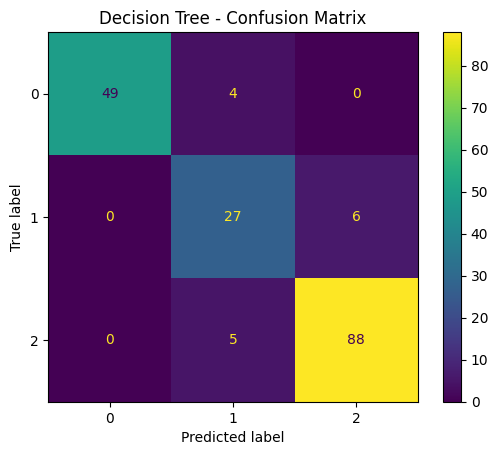

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Naive Bayes
print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

cm_nb = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()


# Decision Tree
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()